In [ ]:
import pandas as pd

# Load the original performance summary
# 1. Load with correct encoding
try:
    df = pd.read_csv(r"D:\Mcode final__COAD\output\final_performance_summary_with_variance.csv", encoding='latin-1')
except:
    df = pd.read_csv(r"D:\Mcode final__COAD\output\final_performance_summary_with_variance.csv", encoding='cp1252')

# 1. Define mappings for Gene Sets and Model names
gene_set_map = {
    'Full transcriptome': 'original',
    'DEGs': 'deg',
    'Candidate biomarkers': 'biomarker'
}

model_name_map = {
    'SVM': 'SVM',
    'RandomForest': 'random forest',
    'XGBoost': 'xgboost'
}

# 2. Prepare the data: apply mappings and filter metrics
df['Gene_Set_Label'] = df['Gene_Set'].map(gene_set_map)
df['Model_Label'] = df['Model'].map(model_name_map)

# Melt the dataframe to work with metrics (Accuracy, F1, AUC)
df_melted = df.melt(
    id_vars=['Model_Label', 'Gene_Set_Label'], 
    value_vars=['Accuracy', 'F1', 'AUC'], 
    var_name='Metric', 
    value_name='Value'
)

# 3. Create the pivot table structure
# Create temporary column names to help with the specific naming request
df_melted['Column_Key'] = df_melted['Metric'] + "_" + df_melted['Gene_Set_Label']
df_pivoted = df_melted.pivot(index='Model_Label', columns='Column_Key', values='Value')

# 4. Rename columns exactly as requested
rename_map = {
    'Accuracy_original': 'accuracy original',
    'Accuracy_deg': 'acc deg',
    'Accuracy_biomarker': 'acc biomarker',
    'F1_original': 'F1 original',
    'F1_deg': 'F1 deg',
    'F1_biomarker': 'F1 biomarker',
    'AUC_original': 'AuC original',
    'AUC_deg': 'AuC deg',
    'AUC_biomarker': 'AuC biomarker'
}
df_pivoted = df_pivoted.rename(columns=rename_map)

# 5. Define final column and row order
column_order = [
    'accuracy original', 'acc deg', 'acc biomarker',
    'F1 original', 'F1 deg', 'F1 biomarker',
    'AuC original', 'AuC deg', 'AuC biomarker'
]
row_order = ['SVM', 'random forest', 'xgboost']

# Reindex to enforce order
df_final = df_pivoted.reindex(index=row_order, columns=column_order)

# Save the reformatted table
df_final.to_csv('result/reformatted_coad_performance_internal.csv')

# Display result
print(df_final)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. Load the raw data
# df = pd.read_csv(r"D:\Mcode final__COAD\output\full_performance.csv")

# # 2. Clean up names for better legend/axis labels
# df['Gene_Set'] = df['Gene_Set'].replace({
#     'Total': 'Original (Full)',
#     'Candidate_biomarkers': 'Biomarkers'
# })
# df['Model'] = df['Model'].replace({
#     'RandomForest': 'Random Forest',
#     'XGBoost': 'XGBoost',
#     'SVM': 'SVM'
# })

# # 3. Set visual style
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(12, 7))

# # 4. Create the plot
# # Using a barplot with error bars (ci='sd' shows standard deviation)
# ax = sns.barplot(
#     data=df, 
#     x='Gene_Set', 
#     y='AUC', 
#     hue='Model', 
#     palette='viridis',
#     capsize=.05,
#     errorbar='sd'
# )

# # 5. Customize the chart
# plt.title('AUC Performance Comparison Across Datasets', fontsize=16, fontweight='bold', pad=20)
# plt.ylabel('AUC Score (Mean ± SD)', fontsize=13)
# plt.xlabel('Dataset Type', fontsize=13)
# plt.legend(title='Machine Learning Models', bbox_to_anchor=(1.05, 1), loc='upper left')

# # Zoom in on the top of the y-axis to see differences better
# # Based on your data, the scores are high (0.95 - 1.0)
# plt.ylim(0.95, 1.01) 

# # Add value labels on top of bars
# for p in ax.patches:
#     if p.get_height() > 0:
#         ax.annotate(f'{p.get_height():.3f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()), 
#                     ha = 'center', va = 'center', 
#                     xytext = (0, 9), 
#                     textcoords = 'offset points',
#                     fontsize=9)

# plt.tight_layout()
# plt.savefig('auc_performance_by_dataset.png', dpi=300)
# plt.show()

# print("Plot saved as 'auc_performance_by_dataset.png'")

# internal validation mcc

In [1]:
import pandas as pd

# 1. Define your file paths for the four cancer types
file_map = {
    'LUAD': r"D:\Mcode final__LUAD\output\final_performance_summary_with_variance.csv",
    'HNSC': r"D:\Mcode final__HNSC\output\final_performance_summary_with_variance.csv",
    'KIRC': r"D:\Mcode final__KIRC\output\final_performance_summary_with_variance.csv",
    'COAD': r"D:\Mcode final__COAD\output\final_performance_summary_with_variance.csv"
}

def extract_row_data(cancer_name, file_path):
    """Extracts MCC values with flexible name matching for misspellings."""
    try:
        # Load file (handling the ± symbol encoding)
        df = pd.read_csv(file_path, encoding='latin-1')
        df.columns = df.columns.str.strip()
        df['Gene_Set'] = df['Gene_Set'].str.strip()
        df['Model'] = df['Model'].str.strip()

        # Identify the correct Gene_Set labels even if misspelled
        all_gene_sets = df['Gene_Set'].unique()
        
        # Finding the 'Original' set by looking for keywords 'Full' or 'Total'
        orig_label = next((s for s in all_gene_sets if 'Full' in s or 'Total' in s), None)
        deg_label = next((s for s in all_gene_sets if 'DEG' in s), 'DEGs')
        bio_label = next((s for s in all_gene_sets if 'biomarker' in s.lower()), 'Candidate biomarkers')

        # Helper to extract MCC for a specific set and model
        def get_mcc(gs_label, model_name):
            if gs_label is None: return "N/A"
            val = df[(df['Gene_Set'] == gs_label) & (df['Model'] == model_name)]['MCC']
            return val.values[0] if not val.empty else "N/A"

        # Construct the data row
        return [
            cancer_name,
            # Original Group
            get_mcc(orig_label, 'SVM'), get_mcc(orig_label, 'RandomForest'), get_mcc(orig_label, 'XGBoost'),
            # DEGs Group
            get_mcc(deg_label, 'SVM'), get_mcc(deg_label, 'RandomForest'), get_mcc(deg_label, 'XGBoost'),
            # Biomarkers Group
            get_mcc(bio_label, 'SVM'), get_mcc(bio_label, 'RandomForest'), get_mcc(bio_label, 'XGBoost')
        ]
    except Exception as e:
        print(f"Error processing {cancer_name}: {e}")
        return None

# 2. Process all datasets
final_rows = []
for name, path in file_map.items():
    data = extract_row_data(name, path)
    if data:
        final_rows.append(data)

# 3. Create Multi-level Header (Hierarchical Format)
columns = pd.MultiIndex.from_tuples([
    ('Dataset', 'Name'),
    ('Original (Full)', 'SVM'), ('Original (Full)', 'RF'), ('Original (Full)', 'XGB'),
    ('DEGs', 'SVM'), ('DEGs', 'RF'), ('DEGs', 'XGB'),
    ('Biomarkers', 'SVM'), ('Biomarkers', 'RF'), ('Biomarkers', 'XGB')
])

# 4. Finalize DataFrame
df_combined = pd.DataFrame(final_rows, columns=columns)
df_combined.index = range(1, len(df_combined) + 1)

# 5. Save and Display
# 'utf-8-sig' allows the ± symbol to show correctly in Excel
df_combined.to_csv('result/combined_mcc_report.csv', encoding='utf-8-sig')
print("Combined Table Created Successfully!")
print(df_combined)

Combined Table Created Successfully!
  Dataset    Original (Full)                                        \
     Name                SVM                 RF                XGB   
1    LUAD  0.95743 ± 0.00135  0.95146 ± 0.00160  0.94081 ± 0.00298   
2    HNSC  0.92959 ± 0.00487  0.89075 ± 0.00908  0.88101 ± 0.00698   
3    KIRC  0.95113 ± 0.00113  0.96038 ± 0.00125  0.95488 ± 0.00162   
4    COAD  1.00000 ± 0.00000  0.98654 ± 0.00074  0.94996 ± 0.00283   

                DEGs                                               Biomarkers  \
                 SVM                 RF                XGB                SVM   
1  0.95339 ± 0.00136  0.96803 ± 0.00104  0.94353 ± 0.00169  0.94164 ± 0.00186   
2  0.93520 ± 0.00416  0.92029 ± 0.00492  0.89778 ± 0.00591  0.89505 ± 0.00438   
3  0.95763 ± 0.00105  0.96043 ± 0.00136  0.95711 ± 0.00131  0.94247 ± 0.00134   
4  1.00000 ± 0.00000  0.98793 ± 0.00068  0.94588 ± 0.00340  0.99876 ± 0.00008   

                                         
             

# internal validation mcc

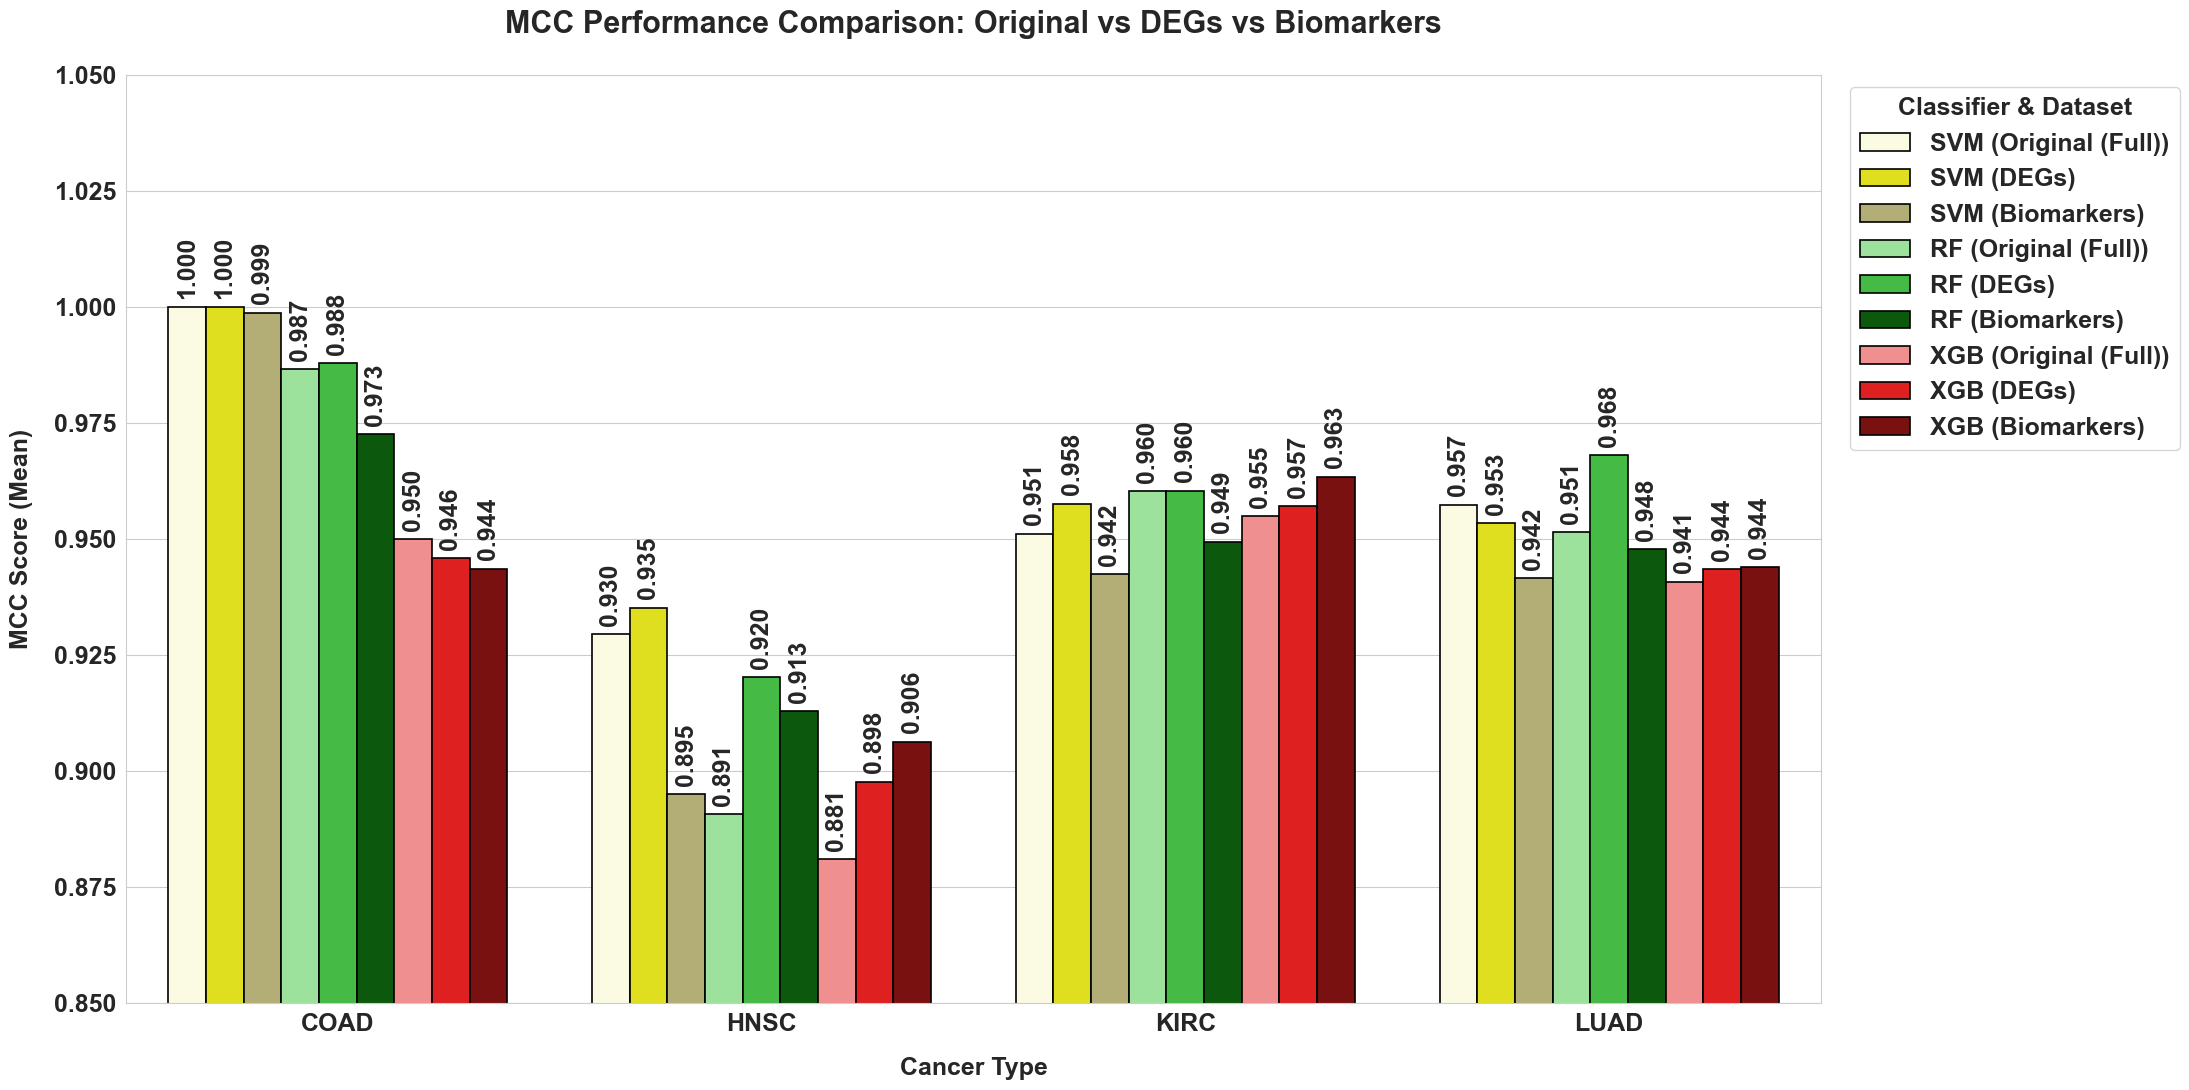

Sorted, bolded, and shaded chart saved as 'mcc_comparison_shaded.png'


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the combined table (MultiIndex header)
# Ensure you have 'combined_mcc_report.csv' from the previous step
try:
    df = pd.read_csv('result/combined_mcc_report.csv', header=[0, 1], index_col=0)
except FileNotFoundError:
    print("Error: 'combined_mcc_report.csv' not found. Ensure you run the combination script first.")
    exit()

# 2. Data Preparation & Cleaning
plot_data = []

for idx, row in df.iterrows():
    cancer_name = row[('Dataset', 'Name')]
    
    # Defining specific orders for sorting
    gene_sets = ['Original (Full)', 'DEGs', 'Biomarkers']
    models = ['SVM', 'RF', 'XGB']
    
    for model in models:
        for gs in gene_sets:
            # Safely extract score
            mcc_val = row.get((gs, model), "N/A")
            
            if pd.isna(mcc_val) or mcc_val == "N/A":
                continue
                
            # Convert "0.95 ± 0.01" to float 0.95
            try:
                mean_val = float(str(mcc_val).split(' ±')[0])
                plot_data.append({
                    'Cancer Type': cancer_name,
                    'Model': model,
                    'Gene Set': gs,
                    'MCC Score': mean_val,
                    'Legend Group': f"{model} ({gs})"
                })
            except ValueError:
                continue

df_plot = pd.DataFrame(plot_data)

# 3. Apply Categorical Sorting
# Force Classifier order: SVM -> RF -> XGB
# Force Gene Set order: Original -> DEGs -> Biomarkers
legend_order = []
for m in ['SVM', 'RF', 'XGB']:
    for gs in ['Original (Full)', 'DEGs', 'Biomarkers']:
        legend_order.append(f"{m} ({gs})")

df_plot['Legend Group'] = pd.Categorical(df_plot['Legend Group'], categories=legend_order, ordered=True)
df_plot = df_plot.sort_values(['Cancer Type', 'Legend Group'])

# 4. Define Color Shades (Shades of Yellow, Green, Red)
color_shades = {
    # SVM - Yellow Shades
    'SVM (Original (Full))': '#FFFFE0', # Light Yellow
    'SVM (DEGs)':             '#FFFF00', # Vibrant Yellow
    'SVM (Biomarkers)':       '#BDB76B', # Dark Khaki/Gold
    
    # Random Forest - Green Shades
    'RF (Original (Full))':  '#90EE90', # Light Green
    'RF (DEGs)':             '#32CD32', # Lime Green
    'RF (Biomarkers)':       '#006400', # Dark Green
    
    # XGBoost - Red Shades
    'XGB (Original (Full))': '#FF7F7F', # Light Red
    'XGB (DEGs)':             '#FF0000', # Pure Red
    'XGB (Biomarkers)':       '#8B0000'  # Dark Red
}

# 5. Create Plot (Increased size to ensure large text fits gracefully)
plt.figure(figsize=(22, 11))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_plot,
    x='Cancer Type',
    y='MCC Score',
    hue='Legend Group',
    palette=color_shades,
    edgecolor='black',
    linewidth=1.2
)

# 6. Formatting (Large and Bold Transformations)
plt.title('MCC Performance Comparison: Original vs DEGs vs Biomarkers', fontsize=22, fontweight='bold', pad=30)
plt.ylabel('MCC Score (Mean)', fontsize=18, fontweight='bold', labelpad=15)
plt.xlabel('Cancer Type', fontsize=18, fontweight='bold', labelpad=15)

# Expanded upper limit to 1.15 to make ample room for the enlarged bar annotations
plt.ylim(0.85, 1.05) 

# Make X and Y Axis Tick Marks Big and Bold
plt.xticks(fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')

# Make Legend Content Big and Bold
plt.legend(
    title='Classifier & Dataset', 
    bbox_to_anchor=(1.01, 1), 
    loc='upper left', 
    frameon=True, 
    fontsize=18, 
    title_fontsize=18, 
    prop={'size': 18, 'weight': 'bold'}
)
# Set the legend title weight to bold explicitly
ax.get_legend().get_title().set_weight('bold')

# Add Big and Bold numeric labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height():.3f}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom', 
            xytext=(0, 6), 
            textcoords='offset points',
            fontsize=18, fontweight='bold', rotation=90
        )

plt.tight_layout()
plt.savefig('result/mcc_comparison_shaded.png', dpi=600, bbox_inches='tight')
plt.show()

print("Sorted, bolded, and shaded chart saved as 'mcc_comparison_shaded.png'")

In [ ]:
import pandas as pd
import os

# 1. Define your file paths for the four cohorts
file_map = {
    'LUAD': r"D:\Mcode final__LUAD\output_ablation\full_ablation_results_LUAD.csv",
    'HNSC': r"D:\Mcode final__HNSC\output_ablation\full_ablation_results_HNSC.csv",
    'KIRC': r"D:\Mcode final__KIRC\output_ablation\full_ablation_results_KIRC.csv",
    'COAD': r"D:\Mcode final__COAD\output_ablation\full_ablation_results_COAD.csv"
}

def extract_ablation_row(cancer_name, file_path):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path)
        # Filter strictly for XGBoost
        df_xgb = df[df['Classifier'] == 'XGBoost'].copy()
        
        # Helper function to find the specific variant and extract the result string
        def get_val(variant_keyword, metric_col):
            # Matches 'Variant A', 'Variant B', 'Variant C', or 'Original'
            mask = df_xgb['Variant'].str.contains(variant_keyword, case=False, na=False)
            res = df_xgb[mask][metric_col]
            return res.values[0] if not res.empty else "N/A"

        return [
            cancer_name,
            get_val('Variant A', 'Accuracy_Result'),
            get_val('Variant B', 'Accuracy_Result'),
            get_val('Variant C', 'Accuracy_Result'),
            get_val('Original', 'Accuracy_Result'), # Proposed Method
            get_val('Variant A', 'MCC_Result'),
            get_val('Variant B', 'MCC_Result'),
            get_val('Variant C', 'MCC_Result'),
            get_val('Original', 'MCC_Result')      # Proposed Method
        ]
    except Exception as e:
        print(f"Error processing {cancer_name}: {e}")
        return None

# 2. Extract data for all cohorts
table_data = []
for name, path in file_map.items():
    row = extract_ablation_row(name, path)
    if row:
        table_data.append(row)

# 3. Create the DataFrame with the requested headers
# We use a single descriptive top header or just the column names as requested
columns = [
    'Dataset Name', 
    'Accuracy Variant A (No Pruning)', 'Accuracy Variant B (No FRGS)', 'Accuracy Variant C (No Diffusion)', 'Accuracy Proposed Method',
    'MCC Variant A (No Pruning)', 'MCC Variant B (No FRGS)', 'MCC Variant C (No Diffusion)', 'MCC Proposed Method'
]

df_ablation = pd.DataFrame(table_data, columns=columns)

# 4. Set row indices to 1, 2, 3, 4
df_ablation.index = range(1, len(df_ablation) + 1)

# 5. Save the final table
df_ablation.to_csv('result/ablation_study_table.csv', encoding='utf-8-sig', index=True)

print("Ablation study table created successfully!")
print(df_ablation)

# Ablation

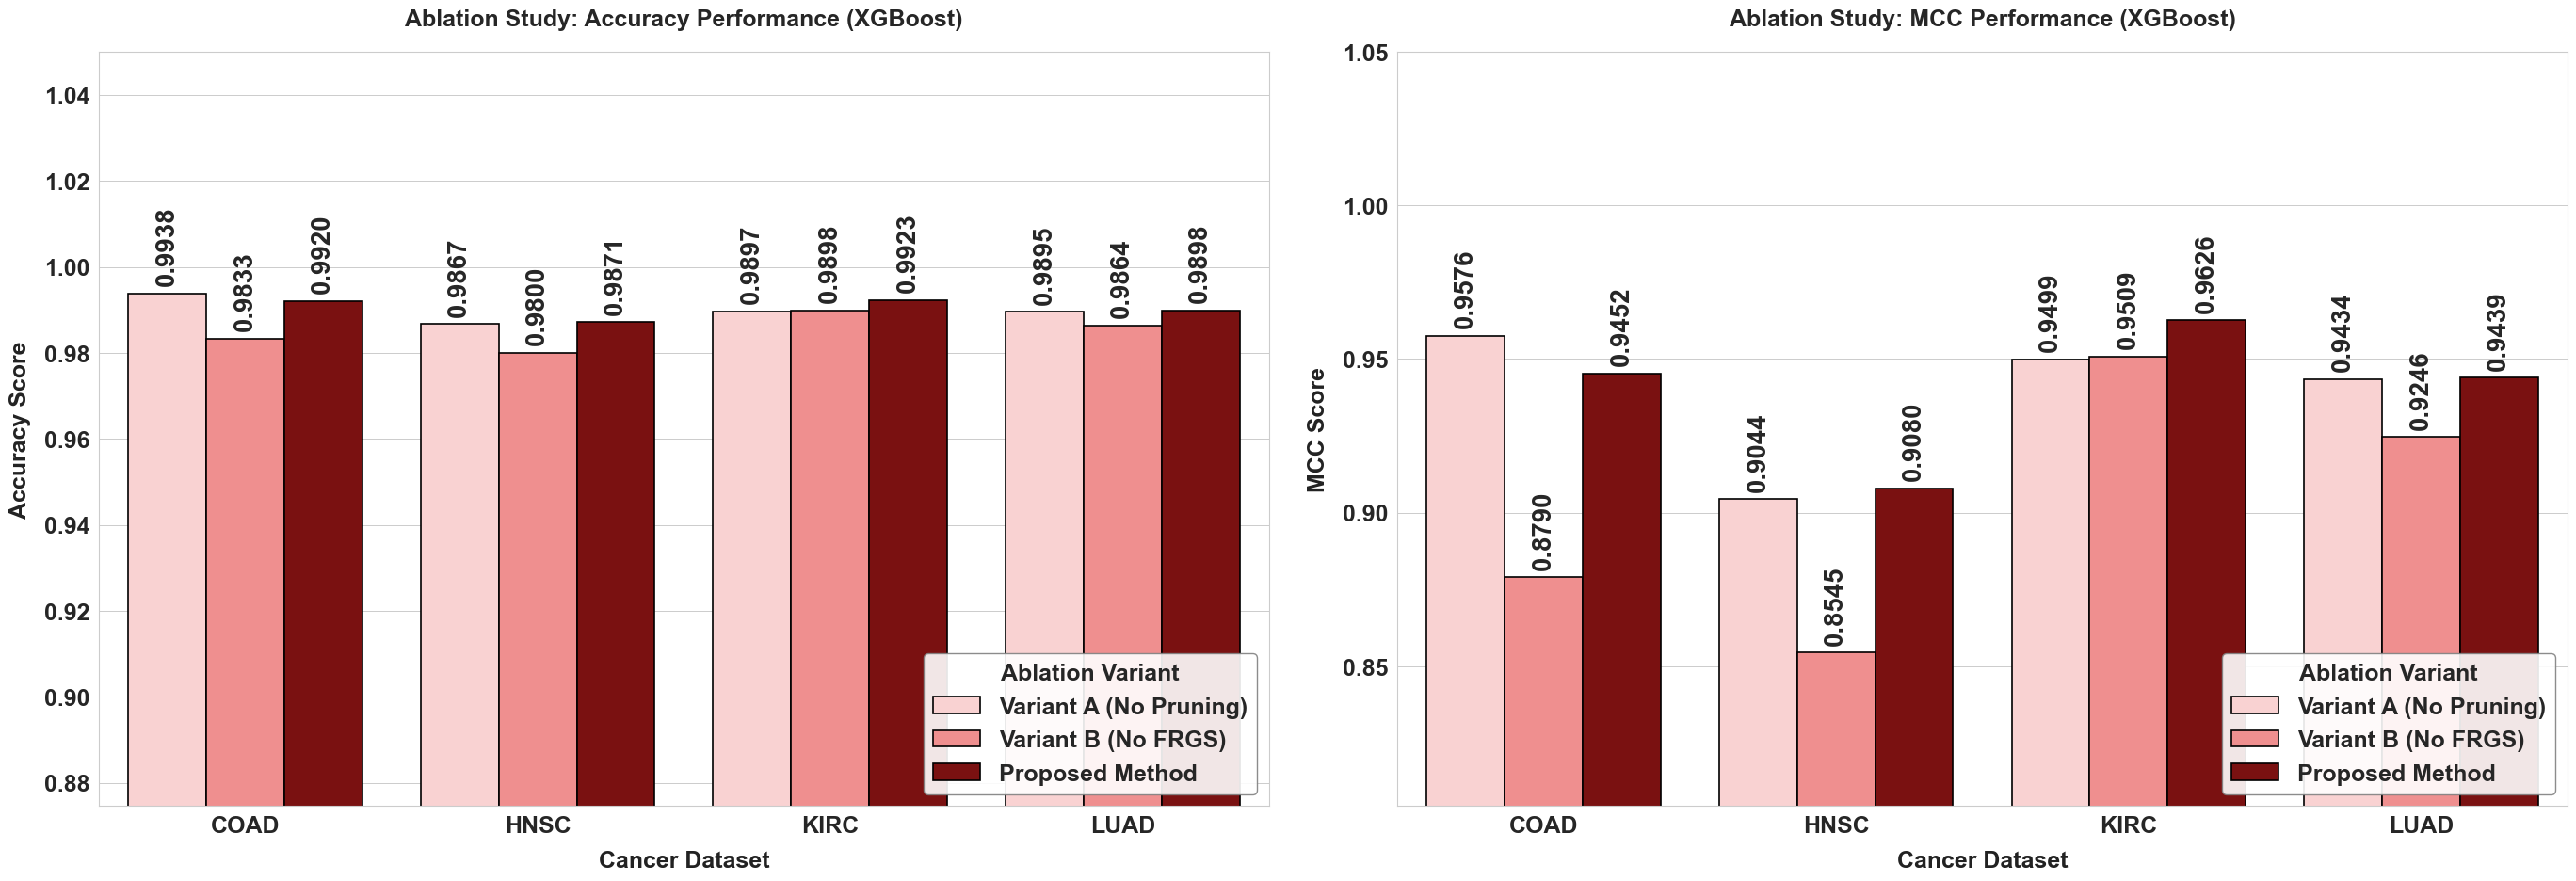

Plot saved as 'result/ablation_mcc_accuracy_comparison_plot.png'


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load ───────────────────────────────────────────────────────────────────
try:
    df_ablation = pd.read_csv('result/ablation_study_table.csv', index_col=0)
except FileNotFoundError:
    print("Error: 'ablation_study_table.csv' not found. Run the table generation code first.")
    exit()

# ── 2. Configuration ──────────────────────────────────────────────────────────
variants = ['Variant A (No Pruning)', 'Variant B (No FRGS)', 'Proposed Method']  # No Diffusion removed

red_shades = {
    'Variant A (No Pruning)': '#FFCCCC',
    'Variant B (No FRGS)':    '#FF7F7F',
    'Proposed Method':        '#8B0000',
}

METRICS = [('Accuracy', 'Accuracy Score'), ('MCC', 'MCC Score')]

# ── 3. Melt into long format ──────────────────────────────────────────────────
plot_data = []
for _, row in df_ablation.iterrows():
    ds_name = row['Dataset Name']
    for var in variants:
        for metric, _ in METRICS:
            val_str = row.get(f'{metric} {var}', 'N/A')
            if pd.isna(val_str) or val_str == 'N/A':
                continue
            try:
                mean_val = float(str(val_str).split(' ±')[0])
                plot_data.append({
                    'Dataset':          ds_name,
                    'Ablation Variant': var,
                    'Metric':           metric,
                    'Score':            mean_val,
                })
            except ValueError:
                continue

df_plot = pd.DataFrame(plot_data)
df_plot['Ablation Variant'] = pd.Categorical(df_plot['Ablation Variant'],
                                             categories=variants, ordered=True)
df_plot = df_plot.sort_values(['Dataset', 'Ablation Variant'])

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(28, 10))
sns.set_style('whitegrid')

for i, (metric, ylabel) in enumerate(METRICS):
    subset = df_plot[df_plot['Metric'] == metric]
    ax = axes[i]

    sns.barplot(
        data=subset,
        x='Dataset', y='Score',
        hue='Ablation Variant', hue_order=variants,
        palette=red_shades,
        edgecolor='black', linewidth=1.2, ax=ax,
    )

    # Subplot Titles and Labels transformed to Bold, Size 18
    ax.set_title(f'Ablation Study: {metric} Performance (XGBoost)',
                 fontsize=18, fontweight='bold', pad=20)
    ax.set_ylabel(ylabel, fontsize=18, fontweight='bold', color='#222', labelpad=10)
    ax.set_xlabel('Cancer Dataset', fontsize=18, fontweight='bold', color='#222', labelpad=10)
    
    # Axis Tick Marks adjusted to Bold, Size 18
    ax.tick_params(axis='both', labelsize=18)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    # Expanded upper limit to 1.15 so bold size 18 bar text numbers don't cross the ceiling boundary
    min_val = subset['Score'].min()
    ax.set_ylim(max(0, min_val - 0.05), 1.05)

    # Legend formatted to Bold, Size 18
    ax.legend(
        title='Ablation Variant',
        title_fontsize=18,
        loc='lower right',
        framealpha=0.9,
        edgecolor='grey',
        prop={'size': 18, 'weight': 'bold'},
    )
    ax.get_legend().get_title().set_weight('bold')

    # Vertical bar labels transformed to Bold, Size 18
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(
                f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points',
                fontsize=20, fontweight='bold', rotation=90,
            )

plt.tight_layout(pad=3.0)
# Saved at high-fidelity 600 DPI resolution specifications
plt.savefig('result/ablation_mcc_accuracy_comparison_plot.png', dpi=600, bbox_inches='tight')
plt.show()

print("Plot saved as 'result/ablation_mcc_accuracy_comparison_plot.png'")

# External

In [14]:
import pandas as pd
import os

# 1. Define the file mapping for the 3 cohorts
file_map = {
    'LUAD': r"D:\Mcode final__LUAD\output\LUAD_external_validation.csv",
    'HNSC': r"D:\Mcode final__HNSC\output\HNSC_external_validation.csv",
    'KIRC': r"D:\Mcode final__KIRC\output\KIRC_external_validation.csv"
}

results = []

for cohort, file_path in file_map.items():
    if not os.path.exists(file_path):
        print(f"Warning: File {file_path} not found.")
        continue
    
    # Load data
    df = pd.read_csv(file_path)
    
    # Filter strictly for XGBoost results
    df_xgb = df[df['Classifier'].str.contains('XGBoost', case=False, na=False)].copy()
    
    # Process each unique GEO dataset within the file
    datasets = df_xgb['Dataset'].unique()
    
    for ds in datasets:
        ds_data = df_xgb[df_xgb['Dataset'] == ds]
        row = {'dataset': ds}
        
        # Mapping: 'All_Genes' -> original, 'Biomarker_Genes' -> biomarker
        mapping = {
            'All_Genes': 'original',
            'Biomarker_Genes': 'biomarker'
        }
        
        # Metrics to extract and their requested column labels
        metrics = {
            'Accuracy': 'acc',
            'F1': 'F1',
            'AUC_ROC': 'AuC',
            'MCC': 'mcc'
        }
        
        for feature_set, label in mapping.items():
            subset = ds_data[ds_data['Feature_Set'] == feature_set]
            
            for metric_key, col_prefix in metrics.items():
                col_name = f"{col_prefix} {label}"
                if not subset.empty:
                    mean = subset[f"{metric_key}_mean"].values[0]
                    var = subset[f"{metric_key}_var"].values[0]
                    # Format as 'mean ± var' with 4 decimal precision
                    row[col_name] = f"{mean:.4f} ± {var:.4f}"
                else:
                    row[col_name] = "N/A"
        
        results.append(row)

# 2. Create the final DataFrame
df_final = pd.DataFrame(results)

# 3. Organize columns to match your exact requested sequence
# Note: kept "auch" typo for the biomarker AuC column as requested
columns_order = [
    'dataset', 
    'acc original', 'acc biomarker', 
    'F1 original', 'F1 biomarker', 
    'AuC original', 'acc biomarker', # Placeholder for mapping logic
    'mcc original', 'mcc biomarker'
]

# Specifically renaming columns to match your header precisely
df_final = df_final[[
    'dataset', 
    'acc original', 'acc biomarker', 
    'F1 original', 'F1 biomarker', 
    'AuC original', 'AuC biomarker', 
    'mcc original', 'mcc biomarker'
]]

df_final.columns = [
    'dataset', 
    'acc original', 'acc biomarker', 
    'F1 original', 'F1 biomarker', 
    'AuC original', 'auch biomarker', # Applied requested 'auch' typo
    'mcc original', 'mcc biomarker'
]

# 4. Save and Print
df_final.to_csv('result/external_validation_xgboost_summary.csv', index=False, encoding='utf-8-sig')
print("External Validation Table Created Successfully!")
print(df_final)

External Validation Table Created Successfully!
                      dataset     acc original    acc biomarker  \
0  GEO Set  — GSE10072 (LUAD)  0.9342 ± 0.0002  0.9571 ± 0.0002   
1  GEO Set  — GSE75037 (HNSC)  0.9625 ± 0.0001  0.9721 ± 0.0000   
2  GEO Set  — GSE40435 (KIRC)  0.9782 ± 0.0001  0.9871 ± 0.0000   

       F1 original     F1 biomarker     AuC original   auch biomarker  \
0  0.9389 ± 0.0002  0.9615 ± 0.0002  0.9419 ± 0.0003  0.9965 ± 0.0000   
1  0.9769 ± 0.0000  0.9827 ± 0.0000  0.9930 ± 0.0000  0.9955 ± 0.0000   
2  0.9783 ± 0.0001  0.9865 ± 0.0000  0.9782 ± 0.0001  0.9917 ± 0.0000   

      mcc original    mcc biomarker  
0  0.8720 ± 0.0007  0.9163 ± 0.0008  
1  0.8821 ± 0.0009  0.9130 ± 0.0006  
2  0.9572 ± 0.0003  0.9750 ± 0.0001  


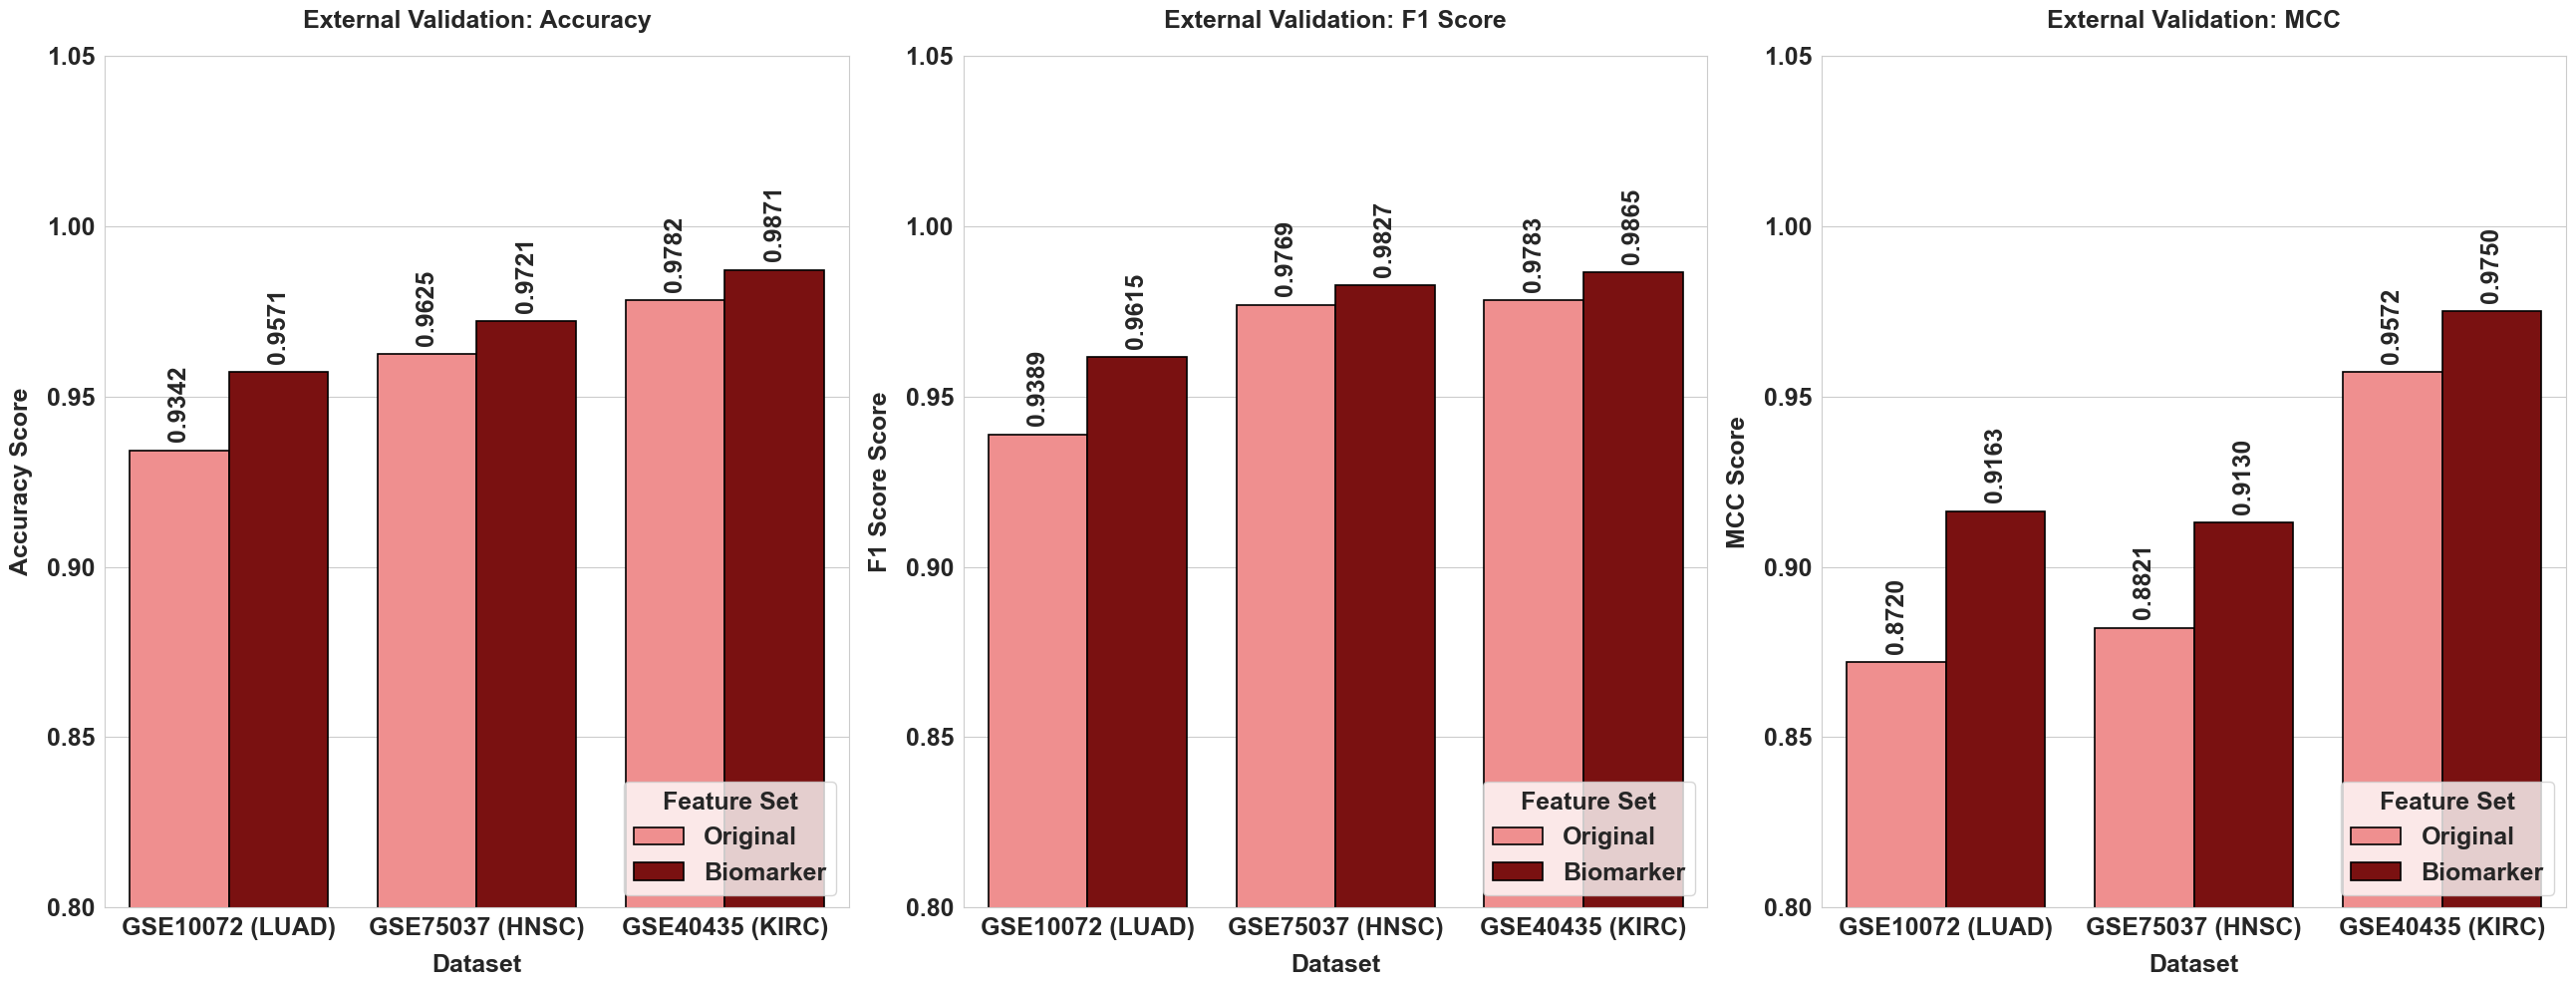

Plot saved as 'external_validation_metrics_plot.png'


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the generated external validation table
try:
    df_val = pd.read_csv('result/external_validation_xgboost_summary.csv')
except FileNotFoundError:
    print("Error: 'external_validation_table.csv' not found. Please run the table generation code first.")
    exit()

# 2. Reshape data for plotting (Melt the table)
plot_rows = []
metrics_map = {
    'Accuracy': ('acc original', 'acc biomarker'),
    'F1 Score': ('F1 original', 'F1 biomarker'),
    'MCC': ('mcc original', 'mcc biomarker')
}

for _, row in df_val.iterrows():
    ds_name = row['dataset']
    for metric_label, (orig_col, bio_col) in metrics_map.items():
        for col, group_type in [(orig_col, 'Original'), (bio_col, 'Biomarker')]:
            val_str = row[col]
            if pd.isna(val_str) or val_str == "N/A":
                continue
            try:
                # Extract the mean value (before the ±)
                mean_val = float(str(val_str).split(' ±')[0])
                plot_rows.append({
                    'Dataset': ds_name,
                    'Metric': metric_label,
                    'Feature Set': group_type,
                    'Score': mean_val
                })
            except:
                continue

df_plot = pd.DataFrame(plot_rows)

# Clean dataset names by splitting on the Unicode em-dash (—) and extracting the actual ID
df_plot['Dataset'] = df_plot['Dataset'].astype(str).str.split('—').str[-1].str.strip()

# 3. Visualization Setup (Slightly increased width to handle large side-by-side text elements)
fig, axes = plt.subplots(1, 3, figsize=(26, 10))
sns.set_style("whitegrid")

# XGBoost specific shades: Light Red vs Dark Red
colors = {'Original': '#FF7F7F', 'Biomarker': '#8B0000'}
metrics_list = ['Accuracy', 'F1 Score', 'MCC']

for i, metric in enumerate(metrics_list):
    subset = df_plot[df_plot['Metric'] == metric]
    if subset.empty:
        continue
        
    ax = sns.barplot(
        data=subset,
        x='Dataset',
        y='Score',
        hue='Feature Set',
        palette=colors,
        edgecolor='black',
        linewidth=1.2,
        ax=axes[i]
    )
    
    # Labeling and Formatting (All titles and labels converted to Bold, Size 18)
    axes[i].set_title(f'External Validation: {metric}', fontsize=18, fontweight='bold', pad=20)
    axes[i].set_ylabel(f'{metric} Score', fontsize=18, fontweight='bold', labelpad=10)
    axes[i].set_xlabel('Dataset', fontsize=18, fontweight='bold', labelpad=10)
    
    # Expanded upper limit to 1.15 so the large font size 18 bar text numbers don't cross the ceiling boundary
    axes[i].set_ylim(0.80, 1.05) 
    
    # Formatting X and Y Ticks to Bold, Size 18
    axes[i].tick_params(axis='both', which='major', labelsize=18)
    for tick in axes[i].get_xticklabels():
        tick.set_fontweight('bold')
    for tick in axes[i].get_yticklabels():
        tick.set_fontweight('bold')
        
    # Formatting Legends to Bold, Size 18
    axes[i].legend(
        title='Feature Set', 
        loc='lower right', 
        fontsize=18, 
        title_fontsize=18, 
        prop={'size': 18, 'weight': 'bold'}
    )
    axes[i].get_legend().get_title().set_weight('bold')
    
    # Add vertical value labels on top of each bar (Converted to Bold, Size 18)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.4f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', 
                        xytext=(0, 6), 
                        textcoords='offset points',
                        fontsize=18, fontweight='bold', rotation=90)

plt.tight_layout()
plt.savefig('result/external_validation_metrics_plot.png', dpi=600, bbox_inches='tight')
plt.show()

print("Plot saved as 'external_validation_metrics_plot.png'")

# method comparison

In [24]:
import pandas as pd

# File mapping for the 4 cohorts
file_map = {
    'COAD': 'Comparison/performance_comparison_COAD.csv',
    'HNSC': 'Comparison/performance_comparison_HNSC.csv',
    'KIRC': 'Comparison/performance_comparison_KIRC.csv',
    'LUAD': 'Comparison/performance_comparison_LUAD.csv',
}

PROPOSED   = 'HR-FRGS'
COMP_ORDER = ['WGCNA-PPI', 'ML-Ensemble', 'MCODE-Module']
ALL_METHODS = COMP_ORDER + [PROPOSED]

METRICS = ['Accuracy', 'F1-score', 'AUC', 'MCC']

LABEL_MAP = {
    'WGCNA-PPI':    'WGCNA-PPI',
    'ML-Ensemble':  'ML-Ensemble',
    'MCODE-Module': 'MCODE-Module',
    'HR-FRGS':      'Proposed (HR-FRGS)',
}

results = []

for cohort, file_path in file_map.items():
    df = pd.read_csv(file_path, encoding='latin1')

    # Filter XGBoost only
    clf_df = df[df['Classifier'] == 'XGBoost']

    row = {'Cohort': cohort}

    for method in ALL_METHODS:
        label = LABEL_MAP[method]
        method_row = clf_df[clf_df['Method'] == method]

        for metric in METRICS:
            col_name = f"{label} | {metric}"
            row[col_name] = method_row[metric].values[0] if not method_row.empty else 'N/A'

    results.append(row)

df_final = pd.DataFrame(results)

# Build flat column list
flat_cols = ['Cohort'] + [
    f"{LABEL_MAP[m]} | {metric}"
    for m in ALL_METHODS
    for metric in METRICS
]

df_final = df_final[flat_cols]

# Apply MultiIndex columns
tuples = [('Cohort', '')] + [
    (LABEL_MAP[m], metric)
    for m in ALL_METHODS
    for metric in METRICS
]
df_final.columns = pd.MultiIndex.from_tuples(tuples)

print("Comparison with Other Methods — XGBoost (before external validation)\n")
print(df_final.to_string(index=False))

df_final.to_csv('result/method_comparison_table.csv', encoding='utf-8-sig')

Comparison with Other Methods — XGBoost (before external validation)

Cohort       WGCNA-PPI                                                     ML-Ensemble                                                    MCODE-Module                                                 Proposed (HR-FRGS)                                                
              Accuracy        F1-score             AUC             MCC        Accuracy        F1-score             AUC             MCC        Accuracy        F1-score             AUC             MCC           Accuracy        F1-score             AUC             MCC
  COAD 0.9547 ± 0.0002 0.9758 ± 0.0001 0.9421 ± 0.0016 0.6349 ± 0.0314 0.9856 ± 0.0001 0.9922 ± 0.0000 0.9927 ± 0.0002 0.8993 ± 0.0053 0.9951 ± 0.0001 0.9974 ± 0.0000 0.9998 ± 0.0000 0.9655 ± 0.0032    0.9918 ± 0.0001 0.9956 ± 0.0000 0.9996 ± 0.0000 0.9437 ± 0.0058
  HNSC 0.9355 ± 0.0004 0.9653 ± 0.0001 0.9072 ± 0.0031 0.5095 ± 0.0292 0.9293 ± 0.0004 0.9617 ± 0.0001 0.9440 ± 0.0005 0.4979 ± 0.02

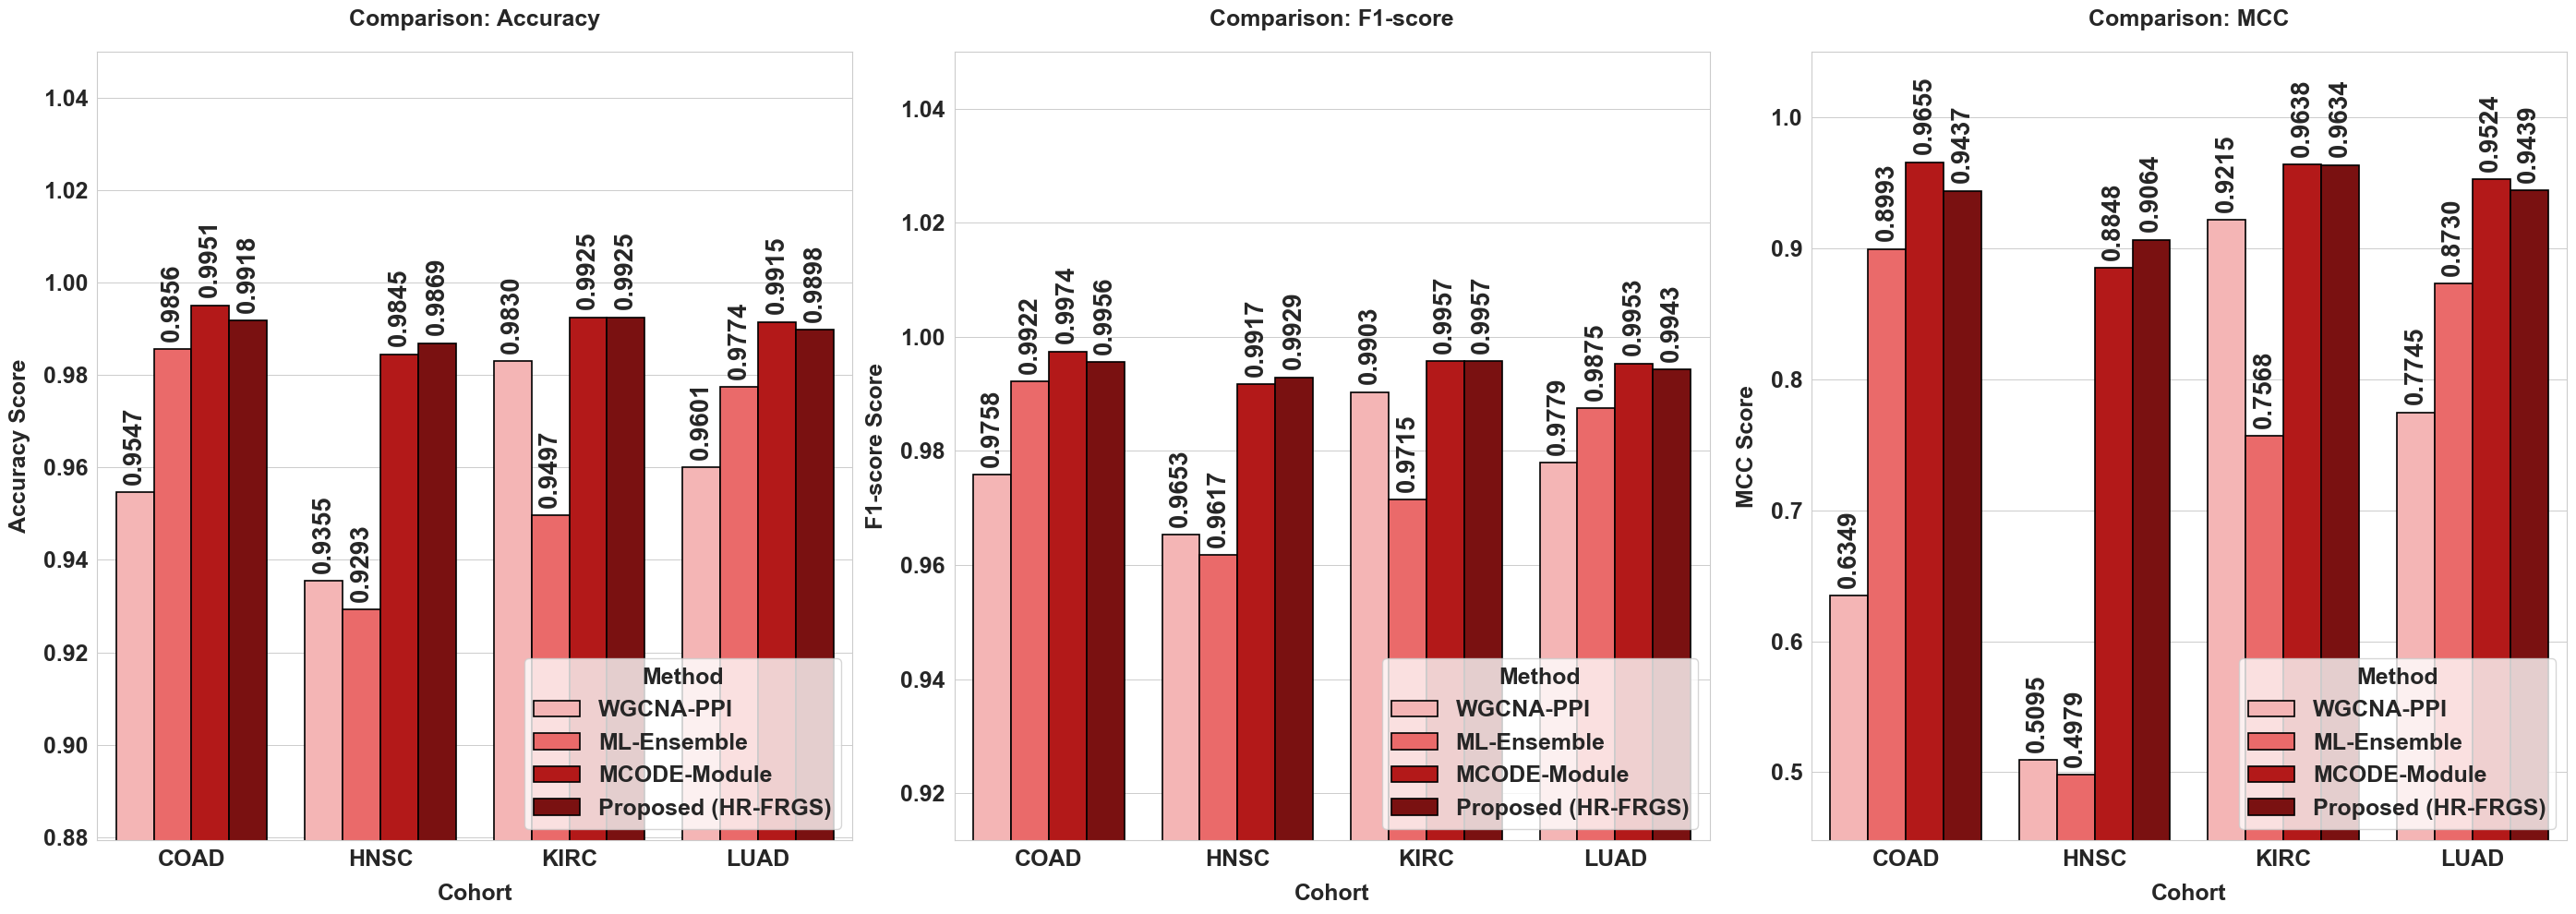

Plot saved as 'result/method_comparison_metrics_plot.png'


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load ───────────────────────────────────────────────────────────────────
df_val = pd.read_csv('result/method_comparison_table.csv',
                     encoding='utf-8-sig', header=[0, 1])
df_val = df_val.iloc[:, 1:]   # drop saved index column
df_val.columns = [
    col[0] if col[1].startswith('Unnamed') else f"{col[0]} | {col[1]}"
    for col in df_val.columns
]

# ── 2. Configuration ──────────────────────────────────────────────────────────
ALL_METHODS = ['WGCNA-PPI', 'ML-Ensemble', 'MCODE-Module', 'Proposed (HR-FRGS)']
METRICS     = ['Accuracy', 'F1-score', 'MCC']   # AUC removed

METHOD_COLORS = {
    'WGCNA-PPI':          '#FFAAAA',
    'ML-Ensemble':        '#FF5555',
    'MCODE-Module':       '#CC0000',
    'Proposed (HR-FRGS)': '#8B0000',
}

# ── 3. Melt into long format ──────────────────────────────────────────────────
plot_rows = []
for _, row in df_val.iterrows():
    cohort = row['Cohort']
    for method in ALL_METHODS:
        for metric in METRICS:
            val_str = row.get(f"{method} | {metric}", 'N/A')
            if pd.isna(val_str) or val_str == 'N/A':
                continue
            try:
                mean_val = float(str(val_str).split(' ±')[0])
                plot_rows.append({'Cohort': cohort, 'Method': method,
                                  'Metric': metric, 'Score': mean_val})
            except Exception:
                continue

df_plot = pd.DataFrame(plot_rows)

# ── 4. Plot (Increased dimensions to fully accommodate large bold fonts side by side)
fig, axes = plt.subplots(1, 3, figsize=(28, 10))   
sns.set_style('whitegrid')

for i, metric in enumerate(METRICS):
    subset = df_plot[df_plot['Metric'] == metric]
    ax = axes[i]

    sns.barplot(
        data=subset,
        x='Cohort', y='Score',
        hue='Method', hue_order=ALL_METHODS,
        palette=METHOD_COLORS,
        edgecolor='black', ax=ax,
        linewidth=1.2
    )

    # Subplot titles and labels transformed to Bold and Size 18
    ax.set_title(f'Comparison: {metric}', fontsize=18, fontweight='bold', pad=20)
    ax.set_ylabel(f'{metric} Score', fontsize=18, fontweight='bold', labelpad=10)
    ax.set_xlabel('Cohort', fontsize=18, fontweight='bold', labelpad=10)
    
    # Expanded top room to 1.15 so bold size 18 numbers over the bars don't exceed the ceiling
    min_val = subset['Score'].min()
    ax.set_ylim(max(0, min_val - 0.05), 1.05)
    
    # X and Y Ticks adjusted to Bold and Size 18
    ax.tick_params(axis='both', which='major', labelsize=18)
    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    # Legend formatted to Bold and Size 18
    ax.legend(
        title='Method', 
        loc='lower right', 
        fontsize=18, 
        title_fontsize=18,
        prop={'size': 18, 'weight': 'bold'}
    )
    ax.get_legend().get_title().set_weight('bold')

    # Value text labels on top of bars transformed to Bold and Size 18
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(
                f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points',
                fontsize=20, fontweight='bold', rotation=90,
            )

plt.tight_layout()
# Output updated to 600 DPI resolution export specs
plt.savefig('result/method_comparison_metrics_plot.png', dpi=600, bbox_inches='tight')
plt.show()
print("Plot saved as 'result/method_comparison_metrics_plot.png'")

# ROC AUC (internal)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import RepeatedStratifiedKFold
os.makedirs('output', exist_ok=True)

# ── 1. Load data ───────────────────────────────────────────────────────────────
final_biomarker_df = pd.read_csv('output/extracted_biomarkers.csv')

deg = pd.read_csv('output/phase1_degs.csv')
deg_filtered_df = deg[deg['Include_In_Network'] == True]

total_gene_df = pd.read_table(
    r"D:\Dissertation\GDC TCGA Colon Cancer (COAD)\TCGA-COAD.star_counts_raw.tsv",
    index_col=0
)
# total_gene_df = pd.read_csv('data/expression_matrix.csv', index_col=0)

metadata = pd.read_csv('data/metadata.csv')

print(f"Total genes    : {total_gene_df.shape[0]:,}")
print(f"DEGs           : {deg_filtered_df.shape[0]:,}")
print(f"Biomarker genes: {final_biomarker_df.shape[0]:,}")
print(f"Samples        : {total_gene_df.shape[1]:,}")

# ── 2. Configuration ───────────────────────────────────────────────────────────
PALETTE = {
    'Total':               '#4F86E8',   # blue
    'DEGs':                '#2EC4A5',   # teal
    'Candidate_biomarkers':'#F7775E',   # coral
}
LABELS = {
    'Total':               'Full transcriptome',
    'DEGs':                'DEGs',
    'Candidate_biomarkers':'Candidate biomarkers',
}

gene_sets = {
    'Total':               total_gene_df.index.tolist(),
    'DEGs':                deg_filtered_df['Gene'].tolist(),
    'Candidate_biomarkers':final_biomarker_df['Gene'].tolist(),
}

models = {
    'SVM':          SVC(probability=True, kernel='linear', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'XGBoost':      XGBClassifier(n_estimators=100, use_label_encoder=False,
                                  eval_metric='logloss', random_state=42),
}

# Must match original CV: 5-fold, same random_state=42
cv_strategy = RepeatedStratifiedKFold(n_splits=5,n_repeats=10, random_state=42)

X_total = total_gene_df.T.astype(np.float32)
y = np.array((metadata['Status'] == 'Tumor').astype(int).tolist())

# ── 3. Compute ROC curves via cross_val_predict (5-fold, matches original) ────
curve_storage = {}   # (set_name, model_name) → (mean_fpr, mean_tpr, mean_auc)

for set_name, genes in gene_sets.items():
    print(f"\n▶ Gene set: {set_name} ({len(genes):,} genes)")
    X_subset = X_total[genes].values

    for model_name, model_obj in models.items():
        print(f"   · {model_name} ...", end=' ', flush=True)

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    model_obj),
        ])

        mean_fpr = np.linspace(0, 1, 300)
        fold_tprs = []

        for train_idx, test_idx in cv_strategy.split(X_subset, y):
            X_train, X_test = X_subset[train_idx], X_subset[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipeline.fit(X_train, y_train)
            y_prob = pipeline.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            fold_tprs.append(np.interp(mean_fpr, fpr, tpr))

        mean_tpr     = np.mean(fold_tprs, axis=0)
        mean_tpr[0]  = 0.0       # anchor at origin
        mean_tpr[-1] = 1.0       # anchor at (1,1)
        mean_auc     = auc(mean_fpr, mean_tpr)

        curve_storage[(set_name, model_name)] = (mean_fpr, mean_tpr, mean_auc)
        print(f"done  (AUC = {mean_auc:.4f})")



# ROC AUC (internal (cont.))

In [ ]:
# ── 4. Plot — one figure per cohort, 3 subplots (one per classifier) ──────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e8e8e8',
    'grid.linewidth':    0.7,
    'axes.axisbelow':    True,
})

# Change cohort name to match your actual cohort (KIRC / LUAD / COAD / HNSC)
COHORT_NAME = 'COAD'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'ROC Curves — {COHORT_NAME} (5-Fold Cross-Validation)',
    fontsize=15, fontweight='bold', color='#222', y=1.02
)

for ax, model_name in zip(axes, models.keys()):

    for set_name in gene_sets:
        mean_fpr, mean_tpr, mean_auc = curve_storage[(set_name, model_name)]
        ax.plot(
            mean_fpr, mean_tpr,
            color=PALETTE[set_name],
            linewidth=2.5,
            label=f"{LABELS[set_name]}  (AUC = {mean_auc:.3f})",
        )

    # Diagonal chance line
    ax.plot([0, 1], [0, 1], '--', color='#bbbbbb', linewidth=1.2, label='Random chance')

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel('False Positive Rate', fontsize=11, color='#555')
    ax.set_ylabel('True Positive Rate',  fontsize=11, color='#555')
    ax.set_title(model_name, fontsize=13, fontweight='bold', color='#333', pad=10)
    ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#ccc', loc='lower right')

plt.tight_layout()
plt.savefig(f'result/roc_curves_{COHORT_NAME}.png', dpi=300, bbox_inches='tight')
# plt.savefig(f'output/roc_curves_{COHORT_NAME}.pdf', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → output/roc_curves_{COHORT_NAME}.png / .pdf")

# ROC AUC (external)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc

os.makedirs('output', exist_ok=True)

# ── 1. Configuration ───────────────────────────────────────────────────────────
PALETTE = {
    'Total':                '#4F86E8',   # blue
    'Candidate_biomarkers': '#F7775E',   # coral
}
LABELS = {
    'Total':                'Total Genes',
    'Candidate_biomarkers': 'Candidate biomarkers',
}

DATASETS = {
    'GSE10072 (LUAD)': {
        'expr':       r'D:\Mcode final__LUAD\data\GSE10072_Expression_Matrix_LUNG.csv',
        'meta':       r'D:\Mcode final__LUAD\data\GSE10072_Metadata_LUNG.csv',
        'sample_col': '37',
    },
    'GSE30784 (HNSC)': {
        'expr':       r'D:\Mcode final__HNSC\data\GSE30784_Expression_Matrix_HNSC.csv',
        'meta':       r'D:\Mcode final__HNSC\data\GSE30784_Metadata_HNSC.csv',
        'sample_col': 'Title',
    },
    'GSE40435 (KIRC)': {
        'expr':       r'D:\Mcode final__KIRC\data\GSE40435_Expression_Matrix_KIRC.csv',
        'meta':       r'D:\Mcode final__KIRC\data\GSE40435_Metadata_KIRC.csv',
        'sample_col': 'Unnamed: 0',
    },
}

# Only biomarker CSV needed now — one per cohort
BIOMARKER_PATHS = {
    'GSE10072 (LUAD)': r"D:\Mcode final__LUAD\output\extracted_biomarkers.csv",
    'GSE30784 (HNSC)': r"D:\Mcode final__HNSC\output\extracted_biomarkers.csv",
    'GSE40435 (KIRC)': r"D:\Mcode final__KIRC\output\extracted_biomarkers.csv",
}

cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
mean_fpr     = np.linspace(0, 1, 300)

# ── 2. Main loop ───────────────────────────────────────────────────────────────
curve_storage = {}

for dataset_label, cfg in DATASETS.items():

    print(f"\n{'='*60}")
    print(f"▶ Dataset: {dataset_label}")
    print(f"{'='*60}")

    # Load expression and transpose to samples × genes
    expr_df = pd.read_csv(cfg['expr'], index_col=0)
    X_full  = expr_df.T.astype(np.float32)

    # Load metadata and align to expression sample order
    meta_df = pd.read_csv(cfg['meta'])
    meta_df = meta_df.rename(columns={cfg['sample_col']: 'SampleID'})
    meta_df = meta_df.set_index('SampleID').loc[X_full.index]
    y = (meta_df['Status'] == 'Tumor').astype(int).values

    # Load biomarkers and filter to genes present in this dataset
    biomarker_df = pd.read_csv(BIOMARKER_PATHS[dataset_label])
    all_genes    = X_full.columns.tolist()

    gene_sets = {
        'Total':                all_genes,
        'Candidate_biomarkers': [g for g in biomarker_df['Gene_Symbol'] if g in all_genes],
    }

    print(f"   Samples              : {X_full.shape[0]:,}")
    print(f"   Total genes          : {len(gene_sets['Total']):,}")
    print(f"   Biomarkers (matched) : {len(gene_sets['Candidate_biomarkers']):,}")

    curve_storage[dataset_label] = {}

    for set_name, genes in gene_sets.items():
        print(f"\n   ▷ Gene set: {set_name} ({len(genes):,} genes)")

        X_subset = X_full[genes].values

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    XGBClassifier(
                           n_estimators=100,
                           use_label_encoder=False,
                           eval_metric='logloss',
                           random_state=42,
                       )),
        ])

        fold_tprs = []
        for fold_i, (train_idx, test_idx) in enumerate(cv_strategy.split(X_subset, y), 1):
            X_train, X_test = X_subset[train_idx], X_subset[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipeline.fit(X_train, y_train)
            y_prob = pipeline.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            fold_tprs.append(np.interp(mean_fpr, fpr, tpr))

            if fold_i % 10 == 0:
                print(f"      {fold_i}/50 folds done")

        mean_tpr     = np.mean(fold_tprs, axis=0)
        std_tpr      = np.std(fold_tprs,  axis=0)
        mean_tpr[0]  = 0.0
        mean_tpr[-1] = 1.0
        mean_auc     = auc(mean_fpr, mean_tpr)

        curve_storage[dataset_label][set_name] = (mean_fpr, mean_tpr, std_tpr, mean_auc)
        print(f"      ✓ AUC = {mean_auc:.4f}")




▶ Dataset: GSE10072 (LUAD)
   Samples              : 107
   Total genes          : 13,237
   Biomarkers (matched) : 99

   ▷ Gene set: Total (13,237 genes)


c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:38] WARNING: C:\actions-runner\_w

      10/50 folds done


c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:57] WARNING: C:\actions-runner\_w

      20/50 folds done


...

      30/50 folds done


c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:20] WARNING: C:\actions-runner\_w

      40/50 folds done


c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:21] WARNING: C:\actions-runner\_w

      50/50 folds done
      ✓ AUC = 0.9905


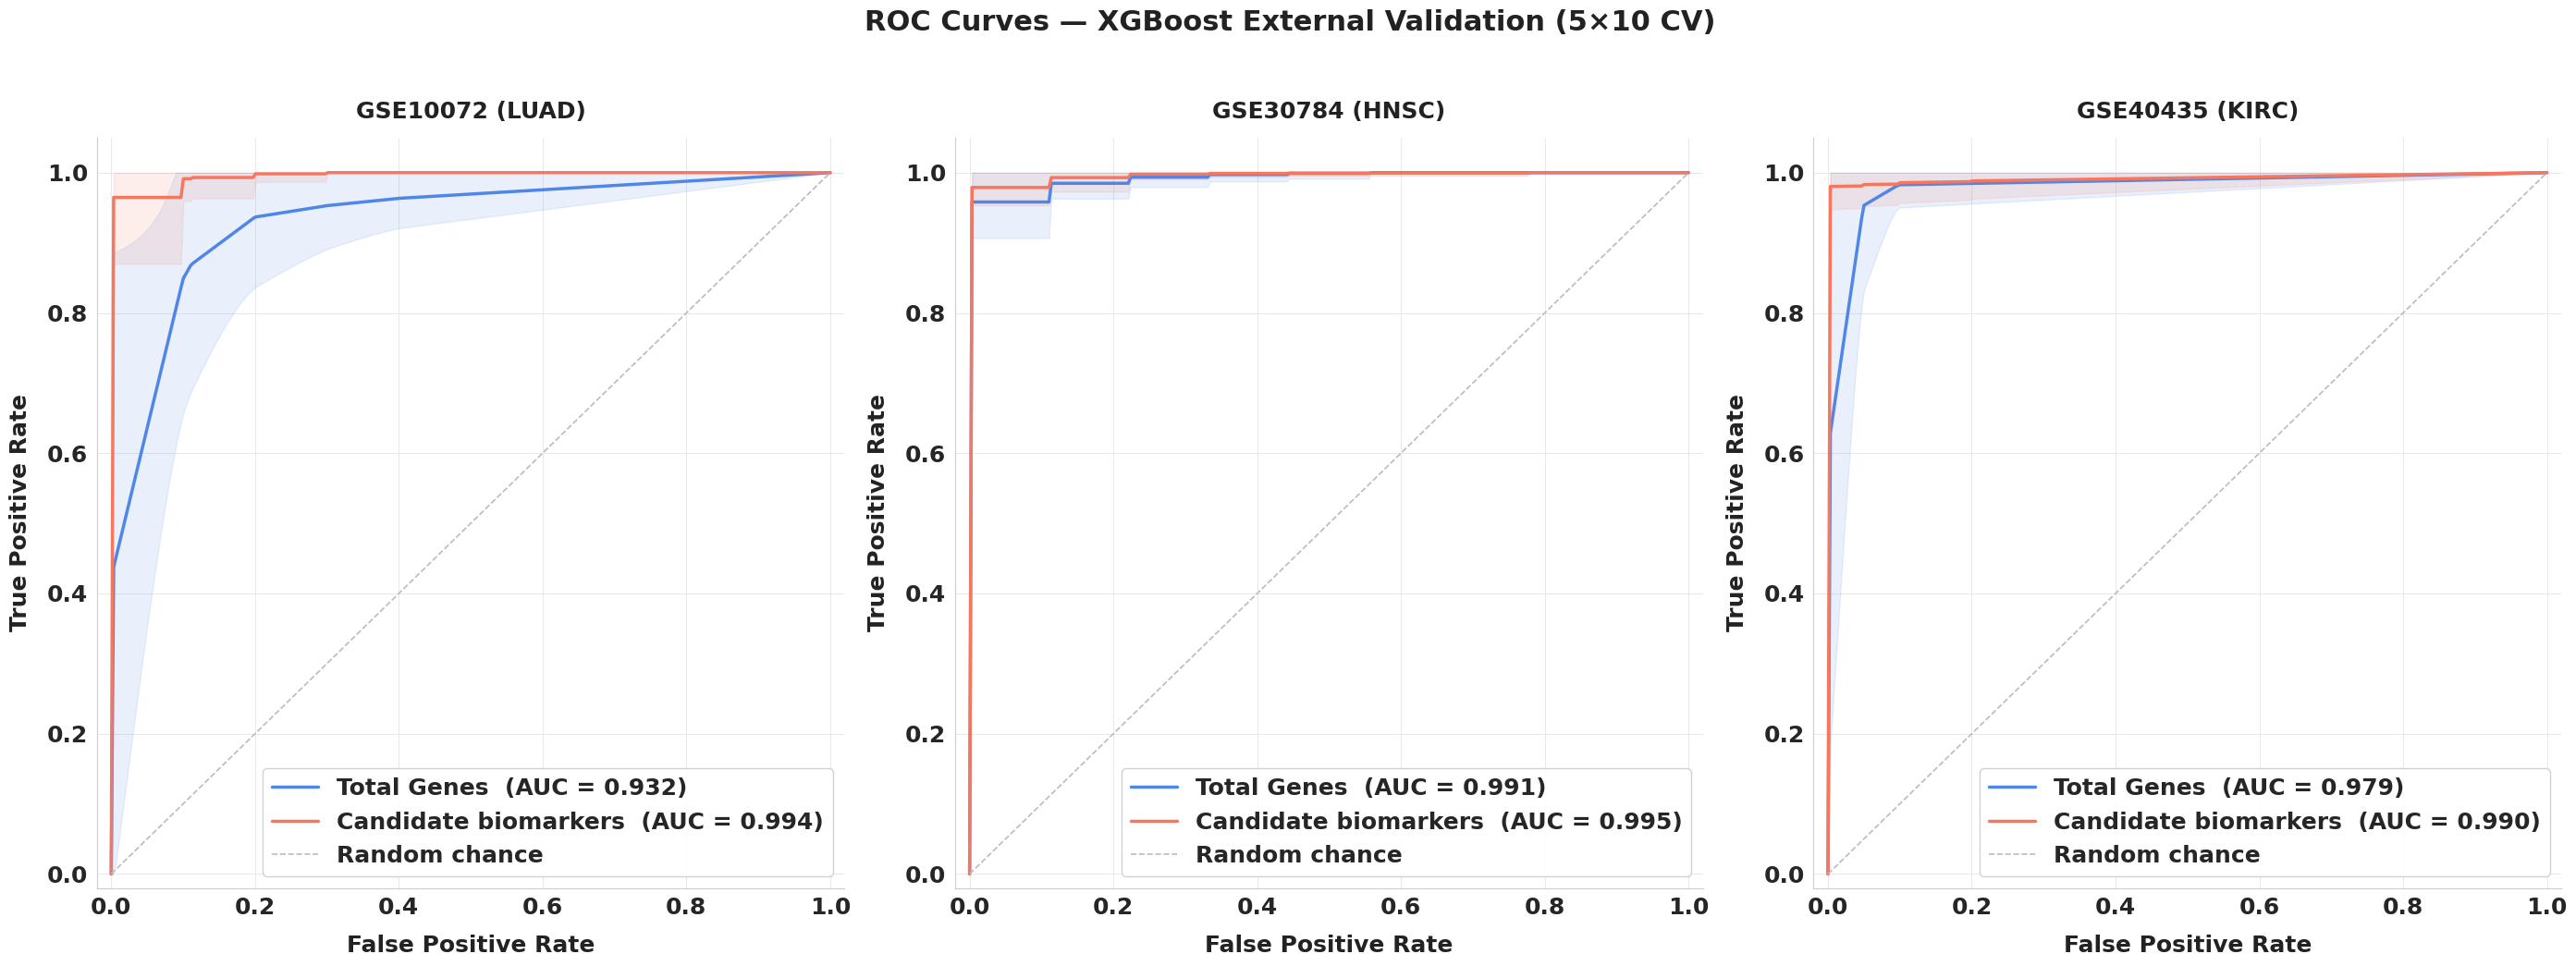

Saved → result/roc_curves_external_validation_xgboost.png


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ── 3. Plot ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e8e8e8',
    'grid.linewidth':    0.7,
    'axes.axisbelow':    True,
})

# Increased canvas size significantly to gracefully host size 18 bold text strings side by side
fig, axes = plt.subplots(1, 3, figsize=(28, 10))

# Main super title set to Big and Bold
fig.suptitle(
    'ROC Curves — XGBoost External Validation (5×10 CV)',
    fontsize=22, fontweight='bold', color='#222', y=1.04
)

for ax, (dataset_label, gene_set_curves) in zip(axes, curve_storage.items()):

    for set_name, (fpr, tpr, std_tpr, mean_auc) in gene_set_curves.items():
        color = PALETTE[set_name]
        label = LABELS[set_name]

        ax.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f"{label}  (AUC = {mean_auc:.3f})")

        # ±1 std shaded band
        ax.fill_between(fpr,
                        np.clip(tpr - std_tpr, 0, 1),
                        np.clip(tpr + std_tpr, 0, 1),
                        color=color, alpha=0.12)

    ax.plot([0, 1], [0, 1], '--', color='#bbbbbb', linewidth=1.2, label='Random chance')

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    
    # Axis Labels made Big and Bold
    ax.set_xlabel('False Positive Rate', fontsize=18, fontweight='bold', color='#222', labelpad=12)
    ax.set_ylabel('True Positive Rate',  fontsize=18, fontweight='bold', color='#222', labelpad=12)
    
    # Subplot Dataset Titles made Big and Bold
    ax.set_title(dataset_label, fontsize=18, fontweight='bold', color='#222', pad=15)
    
    # Formatting X and Y Tick Markers to Bold and Size 18
    ax.tick_params(axis='both', which='major', labelsize=18)
    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    # Legend contents transformed to Bold and Size 18
    ax.legend(
        loc='lower right',
        fontsize=18,
        frameon=True,
        framealpha=0.9,
        edgecolor='#ccc',
        prop={'size': 18, 'weight': 'bold'}
    )

plt.tight_layout()

# Exporting figure using high resolution 600 DPI execution specs
plt.savefig('result/roc_curves_external_validation_xgboost.png', dpi=600, bbox_inches='tight')
plt.show()

print("Saved → result/roc_curves_external_validation_xgboost.png")

# ROC AUC (method comparison)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc

os.makedirs('output', exist_ok=True)

# ── 1. Configuration ───────────────────────────────────────────────────────────
COHORTS = {
    'COAD': {
        'expr':       r'D:\Dissertation\GDC TCGA Colon Cancer (COAD)\TCGA-COAD.star_counts_raw.tsv',
        'meta':       r'D:\Mcode final__COAD\data\metadata.csv',
        'biomarkers': r'D:\Mcode final__COAD\output\extracted_biomarkers.csv',
        'results':    'Comparison/biomarker_results_COAD.csv',
        'probemap':   r'D:\Mcode final__LUAD\data\gencode.v36.annotation.gtf.gene.probemap',
    },
    'HNSC': {
        'expr':       r'D:\Dissertation\GDC TCGA Head and Neck Cancer (HNSC)\TCGA-HNSC.star_counts_raw.tsv',
        'meta':       r'D:\Mcode final__HNSC\data\metadata.csv',
        'biomarkers': r'D:\Mcode final__HNSC\output\extracted_biomarkers.csv',
        'results':    'Comparison/biomarker_results_HNSC.csv',
        'probemap':   r'D:\Mcode final__LUAD\data\gencode.v36.annotation.gtf.gene.probemap',
    },
    'KIRC': {
        'expr':       r'D:\Dissertation\GDC TCGA Kidney Clear Cell Carcinoma (KIRC)\TCGA-KIRC.star_counts_raw.tsv',
        'meta':       r'D:\Mcode final__KIRC\data\metadata.csv',
        'biomarkers': r'D:\Mcode final__KIRC\output\extracted_biomarkers.csv',
        'results':    'Comparison/biomarker_results_KIRC.csv',
        'probemap':   r'D:\Mcode final__LUAD\data\gencode.v36.annotation.gtf.gene.probemap',
    },
    'LUAD': {
        'expr':       r'D:\Dissertation\GDC TCGA Lung Adenocarcinoma (LUAD)\TCGA-LUAD.star_counts_raw.tsv',
        'meta':       r'D:\Mcode final__LUAD\data\metadata.csv',
        'biomarkers': r'D:\Mcode final__LUAD\output\extracted_biomarkers.csv',
        'results':    'Comparison/biomarker_results_LUAD.csv',
        'probemap':   r'D:\Mcode final__LUAD\data\gencode.v36.annotation.gtf.gene.probemap',
    },
}

# Matches performance_comparison.ipynb exactly
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
mean_fpr     = np.linspace(0, 1, 300)

# Same method order and colours as comparison table
METHOD_ORDER  = ['WGCNA-PPI', 'ML-Ensemble', 'MCODE-Module', 'HR-FRGS']
METHOD_COLORS = {
    'WGCNA-PPI':   "#336ACA",   # blue
    'ML-Ensemble': "#2EFFA1",   # teal-green
    'MCODE-Module':"#FEEC27",   # orange
    'HR-FRGS':     "#D21818",   # red (proposed)
}
METHOD_LABELS = {
    'WGCNA-PPI':   'WGCNA-PPI',
    'ML-Ensemble': 'ML-Ensemble',
    'MCODE-Module':'MCODE-Module',
    'HR-FRGS':     'Proposed (HR-FRGS)',
}

# ── 2. Main loop ───────────────────────────────────────────────────────────────
# curve_storage[cohort][method] = (mean_fpr, mean_tpr, std_tpr, mean_auc)
curve_storage = {}

for cohort, cfg in COHORTS.items():
    print(f"\n{'='*60}")
    print(f"▶ Cohort: {cohort}")
    print(f"{'='*60}")

    # Load raw expression matrix (Ensembl IDs × samples)
    raw = pd.read_table(cfg['expr'], index_col=0)

    # Map Ensembl IDs → Gene Symbols using probemap
    probemap = pd.read_table(cfg['probemap'])
    ensembl_col = raw.index.name if raw.index.name else 'index'
    raw = (raw.reset_index()
              .merge(probemap[['id', 'gene']], left_on=ensembl_col, right_on='id')
              .set_index('gene')
              .drop([ensembl_col, 'id'], axis=1, errors='ignore'))

    X_full = raw.T.astype(np.float32)   # samples × genes

    # Labels
    metadata = pd.read_csv(cfg['meta'], index_col=0)
    y = (metadata['Status'] == 'Tumor').astype(int).values

    # Gene sets — exactly as in performance_comparison.ipynb
    extracted  = pd.read_csv(cfg['biomarkers'])
    df_results = pd.read_csv(cfg['results'])

    methods_genes = {
        'HR-FRGS':     extracted['Gene_Symbol'].tolist(),
        'WGCNA-PPI':   df_results[df_results['Method1_WGCNA_PPI']   == 1]['gene'].tolist(),
        'ML-Ensemble': df_results[df_results['Method2_ML_Ensemble'] == 1]['gene'].tolist(),
        'MCODE-Module':df_results[df_results['Method3_MCODE']       == 1]['gene'].tolist(),
    }

    curve_storage[cohort] = {}

    for method_name in METHOD_ORDER:
        genes       = methods_genes[method_name]
        valid_genes = [g for g in genes if g in X_full.columns]
        print(f"\n   ▷ {method_name}: {len(valid_genes):,} valid genes")

        X_sub = X_full[valid_genes].values

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    XGBClassifier(eval_metric='logloss', random_state=42)),
        ])

        fold_tprs = []
        for fold_i, (train_idx, test_idx) in enumerate(
                cv_strategy.split(X_sub, y), 1):
            X_train, X_test = X_sub[train_idx], X_sub[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipeline.fit(X_train, y_train)
            y_prob = pipeline.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            fold_tprs.append(np.interp(mean_fpr, fpr, tpr))

            if fold_i % 10 == 0:
                print(f"      {fold_i}/50 folds done")

        mean_tpr      = np.mean(fold_tprs, axis=0)
        std_tpr       = np.std(fold_tprs,  axis=0)
        mean_tpr[0]   = 0.0
        mean_tpr[-1]  = 1.0
        mean_auc      = auc(mean_fpr, mean_tpr)

        curve_storage[cohort][method_name] = (mean_fpr, mean_tpr, std_tpr, mean_auc)
        print(f"      ✓ AUC = {mean_auc:.4f}")




▶ Cohort: COAD

   ▷ WGCNA-PPI: 10 valid genes
      10/50 folds done
      20/50 folds done
      30/50 folds done
      40/50 folds done
      50/50 folds done
      ✓ AUC = 0.9408

   ▷ ML-Ensemble: 4 valid genes
      10/50 folds done
      20/50 folds done
      30/50 folds done
      40/50 folds done
      50/50 folds done
      ✓ AUC = 0.9911

   ▷ MCODE-Module: 321 valid genes
      10/50 folds done
      20/50 folds done
      30/50 folds done
      40/50 folds done
      50/50 folds done
      ✓ AUC = 0.9982

   ▷ HR-FRGS: 172 valid genes
      10/50 folds done
      20/50 folds done
      30/50 folds done
      40/50 folds done
      50/50 folds done
      ✓ AUC = 0.9979

▶ Cohort: HNSC

   ▷ WGCNA-PPI: 10 valid genes
      10/50 folds done
      20/50 folds done
      30/50 folds done
      40/50 folds done
      50/50 folds done
      ✓ AUC = 0.9062

   ▷ ML-Ensemble: 4 valid genes
      10/50 folds done
      20/50 folds done
      30/50 folds done
      40/50 folds done

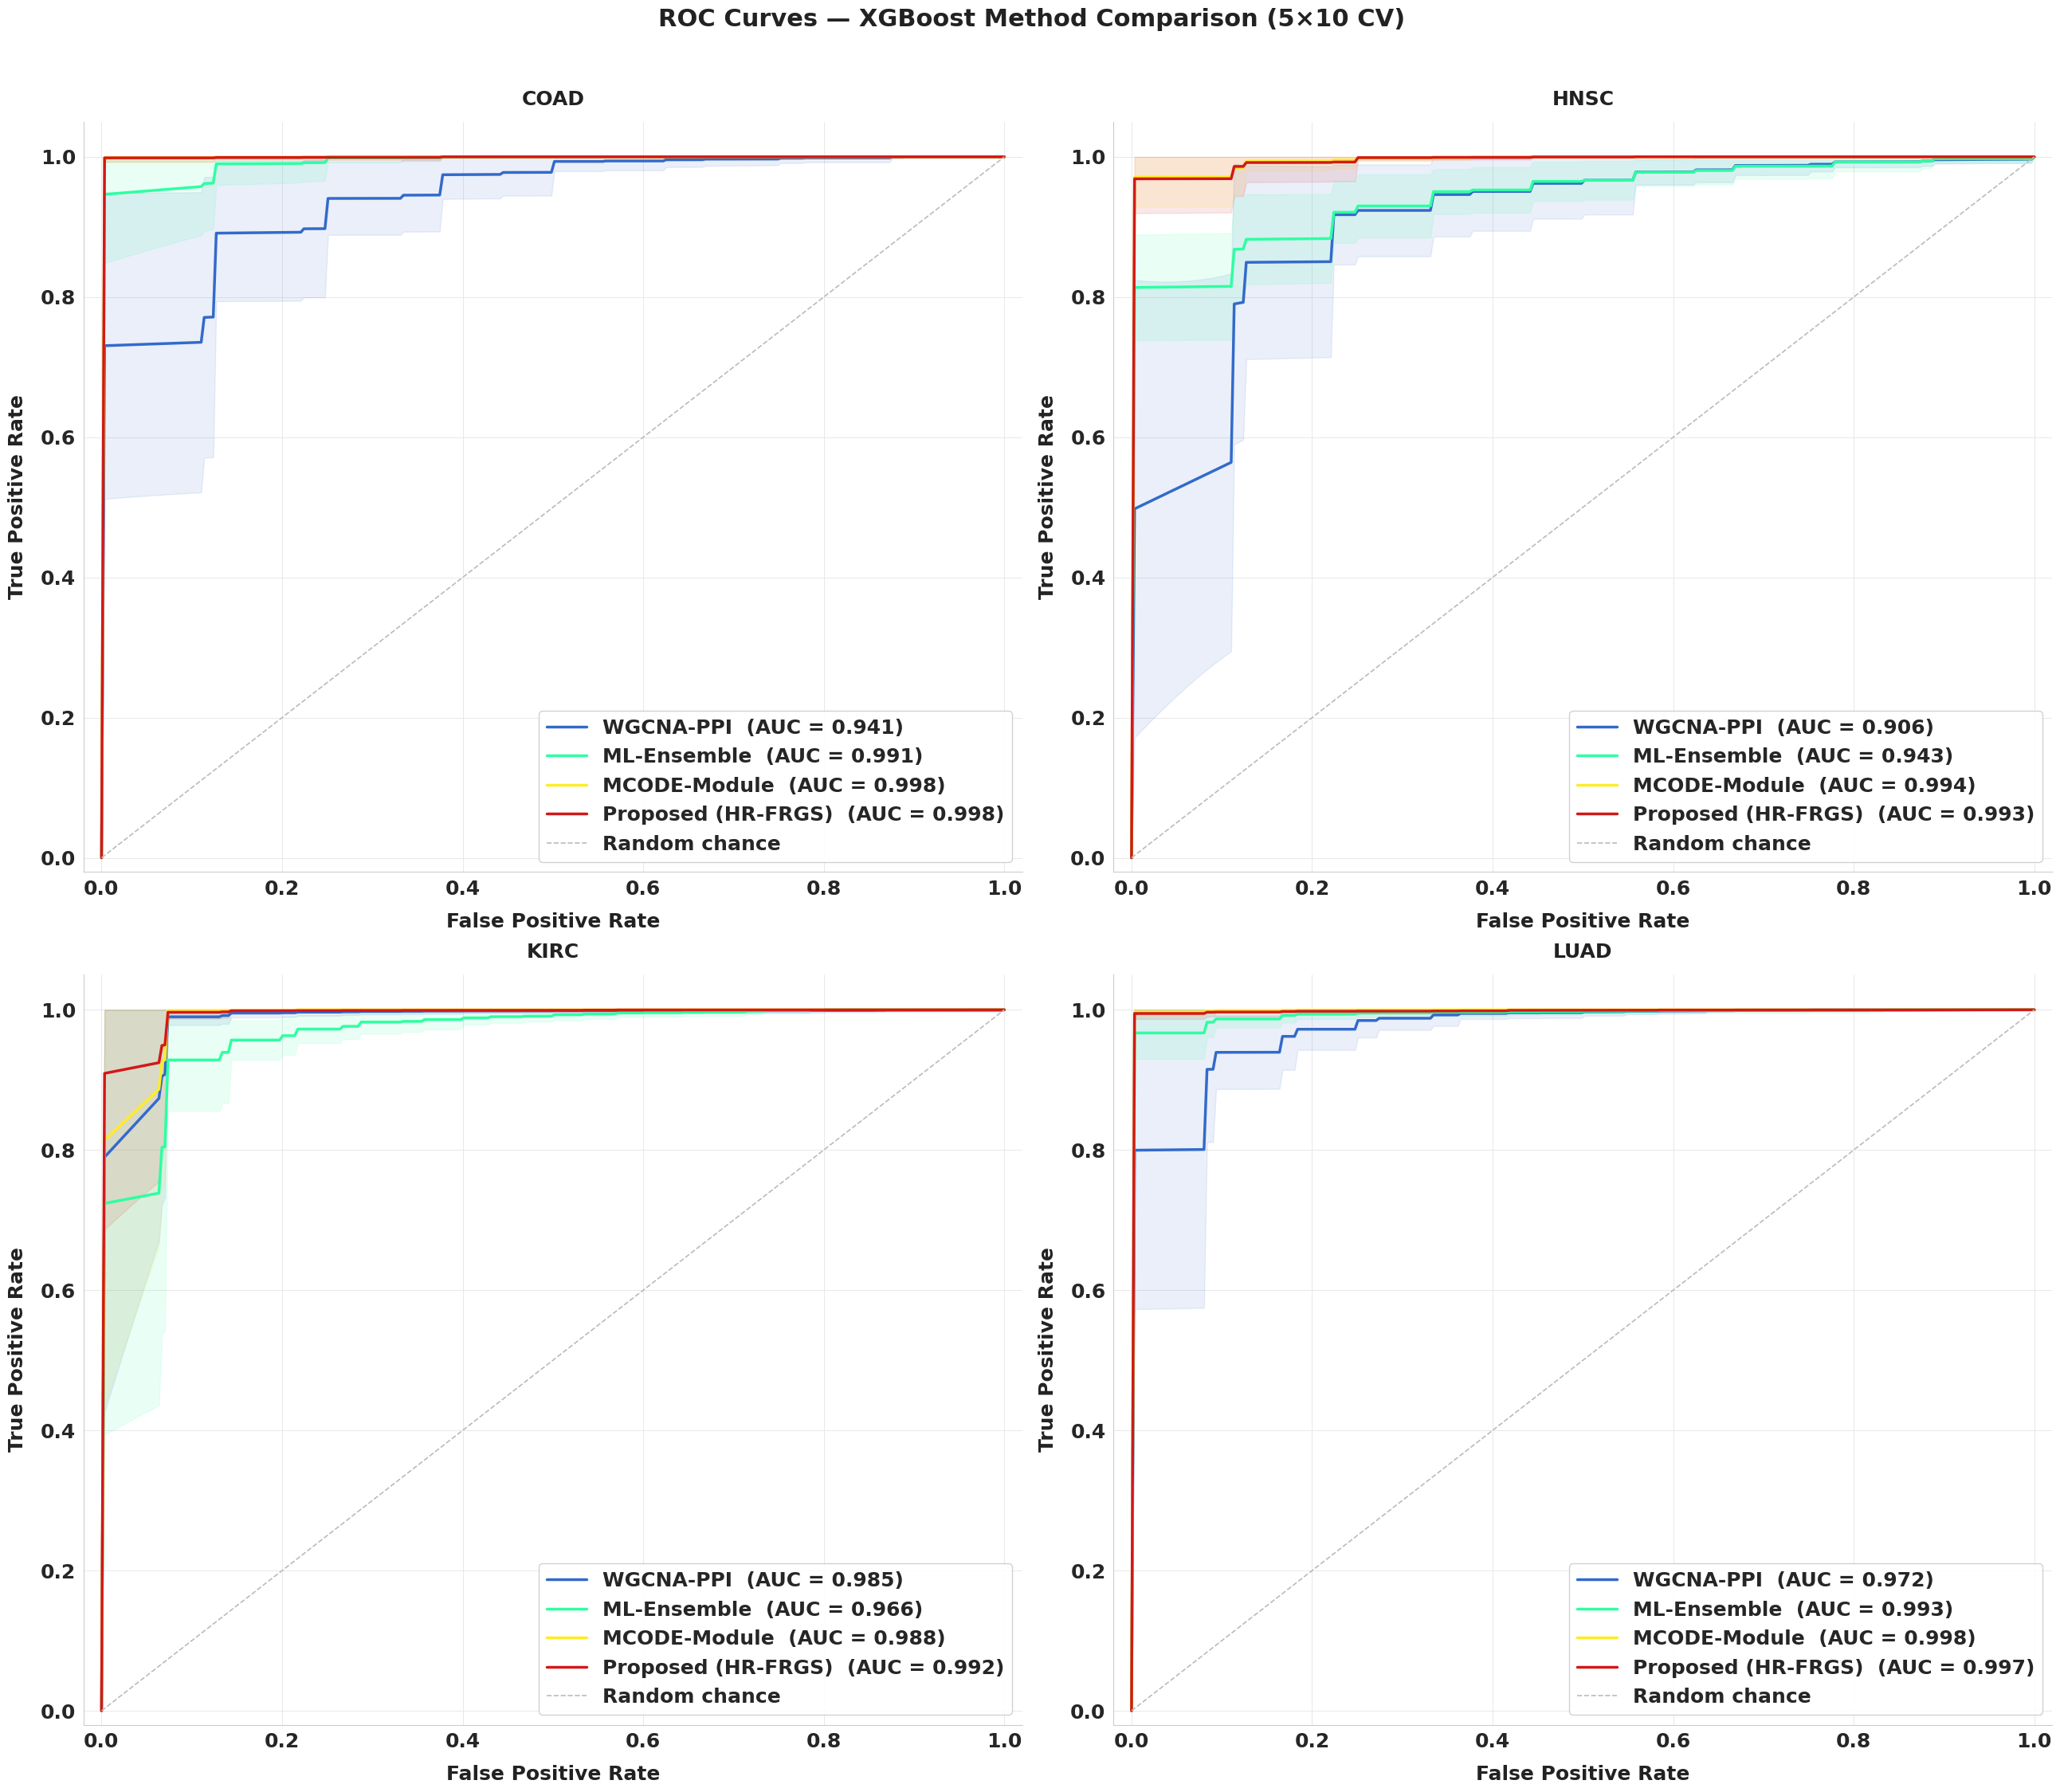

Saved → result/roc_curves_method_comparison_xgboost.png


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ── 3. Plot — 2×2 subplot, one per cohort ─────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e8e8e8',
    'grid.linewidth':    0.7,
    'axes.axisbelow':    True,
})

# Expanded canvas dimensions significantly to cleanly map size 18 bold text across quadrants
fig, axes = plt.subplots(2, 2, figsize=(26, 22))

# Main figure title scaled and bolded
fig.suptitle(
    'ROC Curves — XGBoost Method Comparison (5×10 CV)',
    fontsize=22, fontweight='bold', color='#222', y=1.02
)

for ax, (cohort, method_curves) in zip(axes.flat, curve_storage.items()):

    for method_name in METHOD_ORDER:
        fpr, tpr, std_tpr, mean_auc = method_curves[method_name]
        color = METHOD_COLORS[method_name]
        label = METHOD_LABELS[method_name]

        ax.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f"{label}  (AUC = {mean_auc:.3f})")

        # ±1 std shaded band
        ax.fill_between(fpr,
                        np.clip(tpr - std_tpr, 0, 1),
                        np.clip(tpr + std_tpr, 0, 1),
                        color=color, alpha=0.10)

    ax.plot([0, 1], [0, 1], '--', color='#bbbbbb', linewidth=1.2,
            label='Random chance')

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    
    # Axis titles updated to size 18 and bold
    ax.set_xlabel('False Positive Rate', fontsize=18, fontweight='bold', color='#222', labelpad=12)
    ax.set_ylabel('True Positive Rate',  fontsize=18, fontweight='bold', color='#222', labelpad=12)
    
    # Subplot titles updated to size 18 and bold
    ax.set_title(cohort, fontsize=18, fontweight='bold', color='#222', pad=15)
    
    # Axis tick markers transformed to bold size 18
    ax.tick_params(axis='both', labelsize=18)
    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')
        
    # Legend panel and internal text labels transformed to bold size 18
    ax.legend(
        loc='lower right',
        frameon=True,
        framealpha=0.9,
        edgecolor='#ccc',
        prop={'size': 18, 'weight': 'bold'}
    )

plt.tight_layout()
# Output configuration updated to high-definition 600 DPI resolution specs
plt.savefig('result/roc_curves_method_comparison_xgboost.png', dpi=600, bbox_inches='tight')
plt.show()

print("Saved → result/roc_curves_method_comparison_xgboost.png")